In [1]:
from sqlalchemy import create_engine , text
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from warnings import filterwarnings
filterwarnings("ignore")

In [2]:
engine = create_engine(
    f"mysql+mysqlconnector://{os.environ['DB_USER']}:{os.environ['DB_PASSWORD']}@{os.environ['DB_HOST']}/{os.environ['DB_NAME']}"
)

with engine.connect() as conn:
    result = conn.execute(text("SHOW TABLES"))
    tables = [row[0] for row in result]

print("Total Tables:", len(tables))
print("Table Names:")
for table in tables:
    print("-", table)

Total Tables: 2
Table Names:
- clean_dataset
- student_social_media_and_mental_health


In [3]:
for table in tables:
       query = text(f"SELECT COUNT(*) FROM {table}")
       df = pd.read_sql_query(query, engine)
       print(f"{table}", df.iloc[0,0])
       df = pd.read_sql(f"SELECT * FROM {table}", engine)
       display(df.head(5))

clean_dataset 4998


,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134.0,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73.0,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166.0,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220.0,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237.0,1.0,1.1,5.0,Very High,4.4


student_social_media_and_mental_health 5000


,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134.0,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73.0,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166.0,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220.0,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237.0,1.0,1.1,5.0,Very High,4.4


In [4]:
data = pd.read_sql_query(text("""select * from clean_dataset """),engine)

In [5]:
data.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.750760,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.668406,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


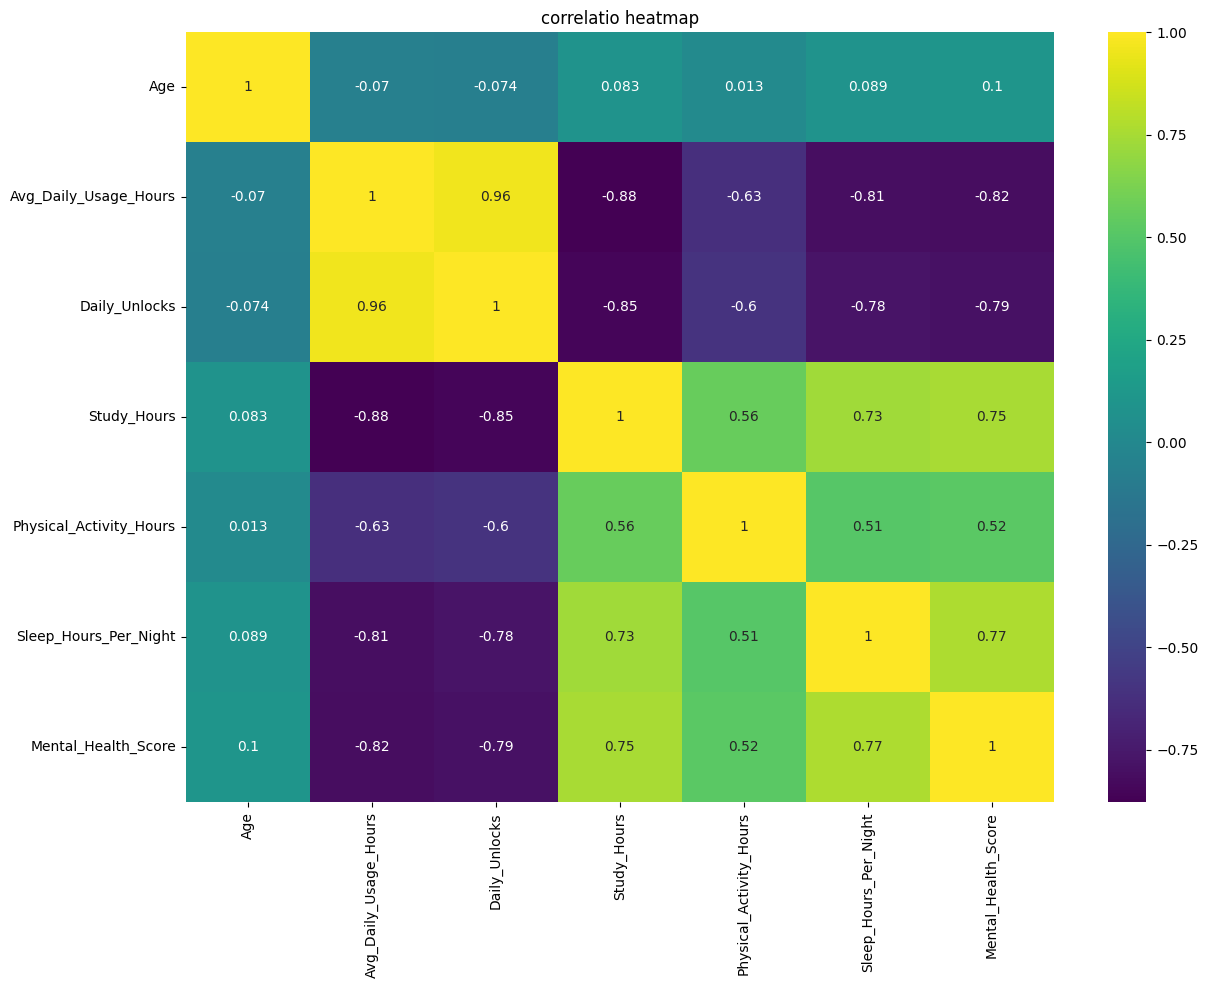

In [9]:
numeric_cols = data.select_dtypes(include=['int64','float64'])
plt.figure(figsize=(14,10))
sns.heatmap(numeric_cols.corr() , annot=True ,cmap="viridis" )
plt.title("correlatio heatmap")
plt.show()

***strong Positive Correlations***

Avg_Daily_Usage_Hours ↔ Daily_Unlocks (0.96)
Almost perfect positive correlation: As average daily phone usage increases, the number of daily unlocks also increases significantly.


Study_Hours ↔ Mental_Health_Score (0.75)
Strong positive correlation: More study hours are associated with higher mental health scores.


Sleep_Hours_Per_Night ↔ Mental_Health_Score (0.77)
Strong positive correlation: More sleep per night is linked to better mental health scores.


Study_Hours ↔ Sleep_Hours_Per_Night (0.73)
Strong positive correlation: More study hours are associated with more sleep hours

***Strong Negative Correlations***


Avg_Daily_Usage_Hours ↔ Study_Hours (-0.88)
Strong negative correlation: Higher phone usage is associated with fewer study hours.


Avg_Daily_Usage_Hours ↔ Sleep_Hours_Per_Night (-0.81)
Strong negative correlation: More phone usage is linked to less sleep.


Avg_Daily_Usage_Hours ↔ Mental_Health_Score (-0.82)
Strong negative correlation: Higher phone usage is associated with lower mental health scores.


Daily_Unlocks ↔ Study_Hours (-0.85)
Strong negative correlation: More daily unlocks are linked to fewer study hours.


Daily_Unlocks ↔ Sleep_Hours_Per_Night (-0.78)
Strong negative correlation: More daily unlocks are associated with less sleep.


Daily_Unlocks ↔ Mental_Health_Score (-0.79)
Strong negative correlation: More daily unlocks are linked to lower mental health scores

***Moderate Correlations***


Physical_Activity_Hours ↔ Study_Hours (0.56)
Moderate positive correlation: More physical activity is somewhat associated with more study hours.


Physical_Activity_Hours ↔ Sleep_Hours_Per_Night (0.51)
Moderate positive correlation: More physical activity is somewhat linked to more sleep.


Physical_Activity_Hours ↔ Mental_Health_Score (0.52)
Moderate positive correlation: More physical activity is somewhat associated with better mental health.



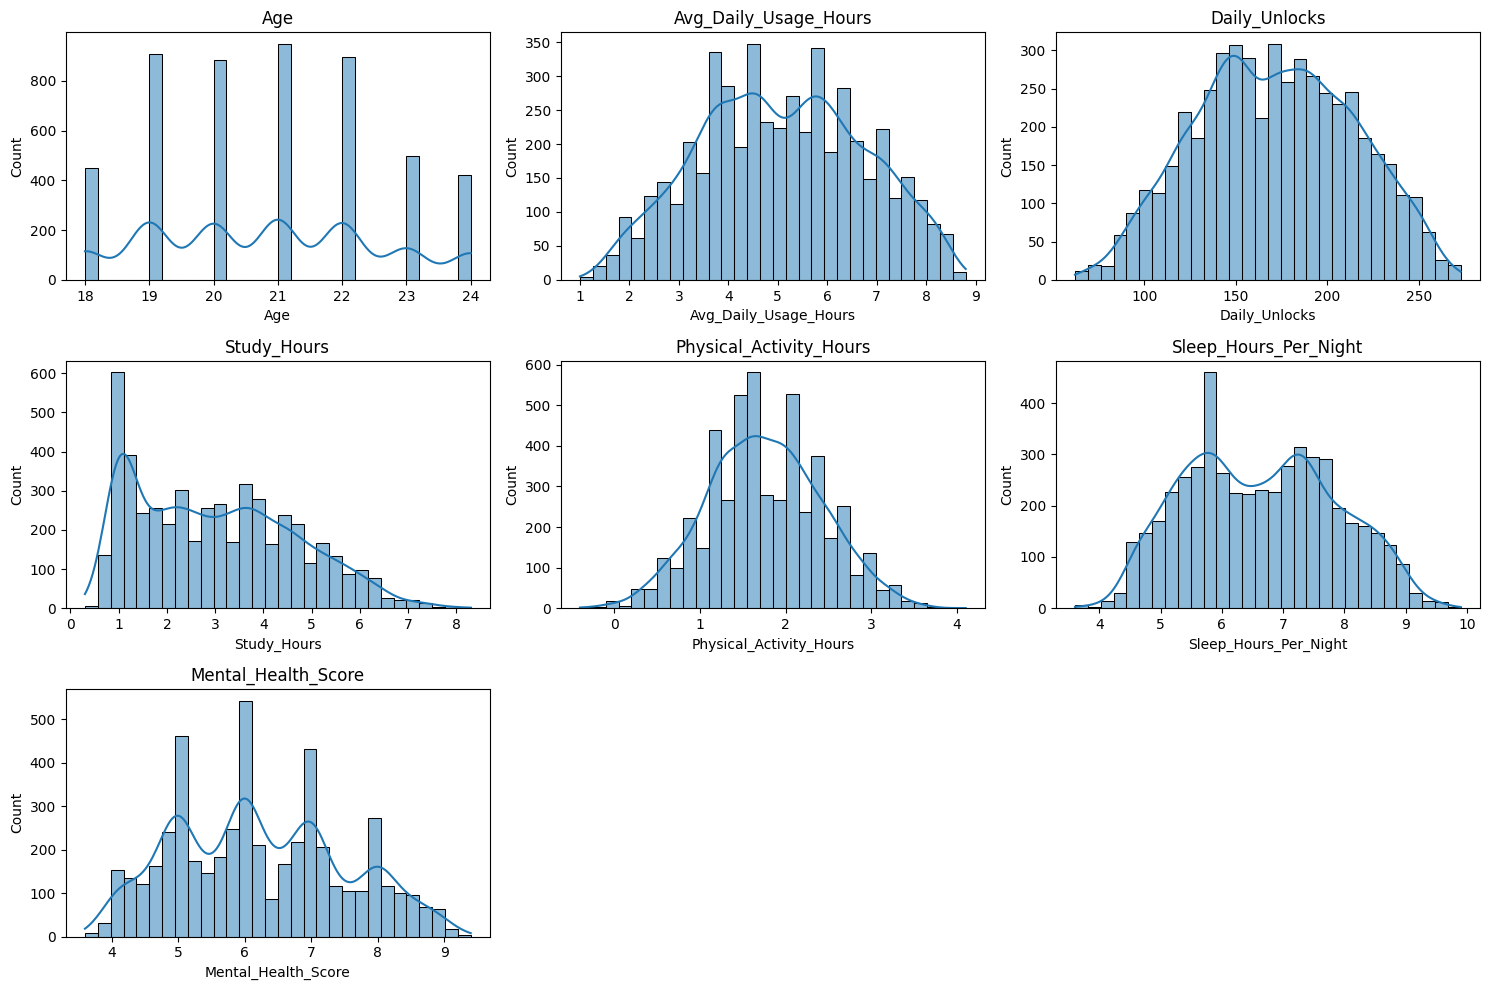

In [12]:
# distribution plot for numerical columns
numerical_cols = df.select_dtypes(include=["float64", "int64"]).columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1) # adjust the number of rows and columns as needed
    sns.histplot(df[col], kde=True , bins = 30)
    plt.title(col)
plt.tight_layout()
plt.show()

# Phase 1: who are this students ?

1 . What is the distribution of students by Academic_Level (High School / Undergraduate / Graduate) and Gender?

,Academic_Level,gender,total_students,pct_of_total
0,Undergraduate,Male,1871,37.43
1,Undergraduate,Female,1759,35.19
2,Graduate,Male,489,9.78
3,Graduate,Female,429,8.58
4,High School,Male,274,5.48
5,High School,Female,176,3.52


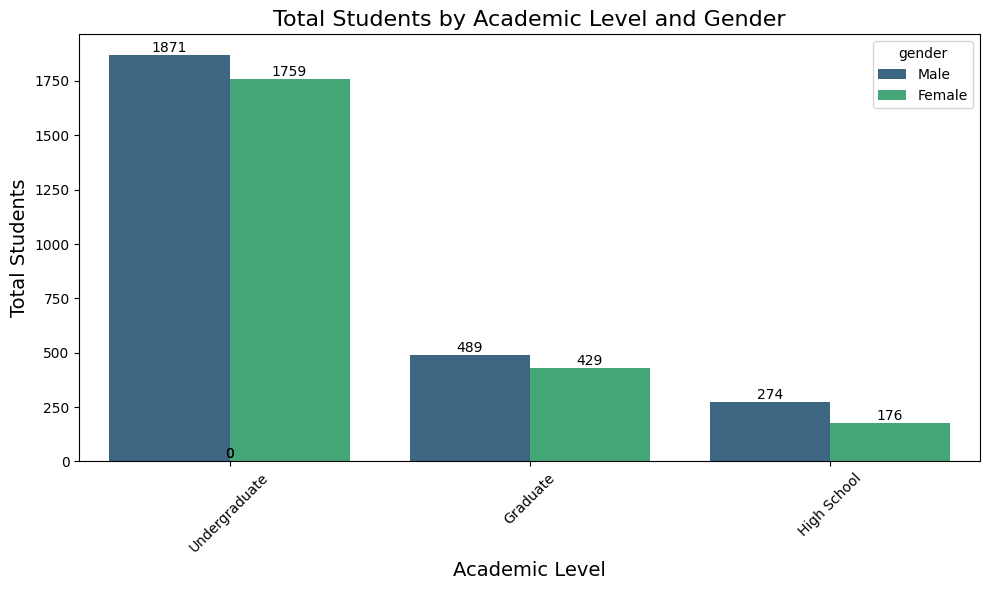

In [30]:
academic_students = pd.read_sql_query(text("""select Academic_Level,gender , count(*) as total_students , 
round(count(*) * 100.0 / sum(count(*)) over(),2) as pct_of_total from clean_dataset 
group by Academic_Level , gender order by total_students desc """),engine)
display(academic_students)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=academic_students,
    x="Academic_Level",
    y="total_students",
    hue="gender",
    palette="viridis"
)

# Add title and labels
plt.title("Total Students by Academic Level and Gender", fontsize=16)
plt.xlabel("Academic Level", fontsize=14)
plt.ylabel("Total Students", fontsize=14)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 5),
        textcoords='offset points'
    )

# Show the plot
plt.tight_layout()
plt.show()

2. Which Most_Used_Platform dominates overall — and does the ranking shift across Academic Levels?

In [42]:
platform = pd.read_sql_query(text("""
WITH platform_counts AS (
    SELECT 
        Academic_Level,
        Most_Used_Platform,
        COUNT(*) AS total_students
    FROM clean_dataset 
    GROUP BY Academic_Level, Most_Used_Platform
),
ranked AS (
    SELECT 
        Academic_Level,
        Most_Used_Platform,
        total_students,
        ROW_NUMBER() OVER (PARTITION BY Academic_Level ORDER BY total_students DESC) AS rank_in_level
    FROM platform_counts
)
SELECT 
    Academic_Level,
    Most_Used_Platform,
    total_students,
    rank_in_level
FROM ranked
ORDER BY total_students desc;"""),engine)
display(platform)

,Academic_Level,Most_Used_Platform,total_students,rank_in_level
0,Undergraduate,Instagram,915,1
1,Undergraduate,TikTok,721,2
2,Undergraduate,Facebook,548,3
3,Undergraduate,YouTube,325,4
4,Undergraduate,LinkedIn,294,5
5,Undergraduate,Twitter,267,6
6,Undergraduate,Snapchat,228,7
7,Undergraduate,WhatsApp,175,8
8,Graduate,Instagram,165,1
9,Graduate,TikTok,148,2


3. What is the distribution of Purpose_Of_Use (Entertainment, Education, Networking, News)?

,Purpose_Of_Use,total_students,pct_of_total
0,Entertainment,2551,51.04
1,Education,1093,21.87
2,Networking,793,15.87
3,News,561,11.22


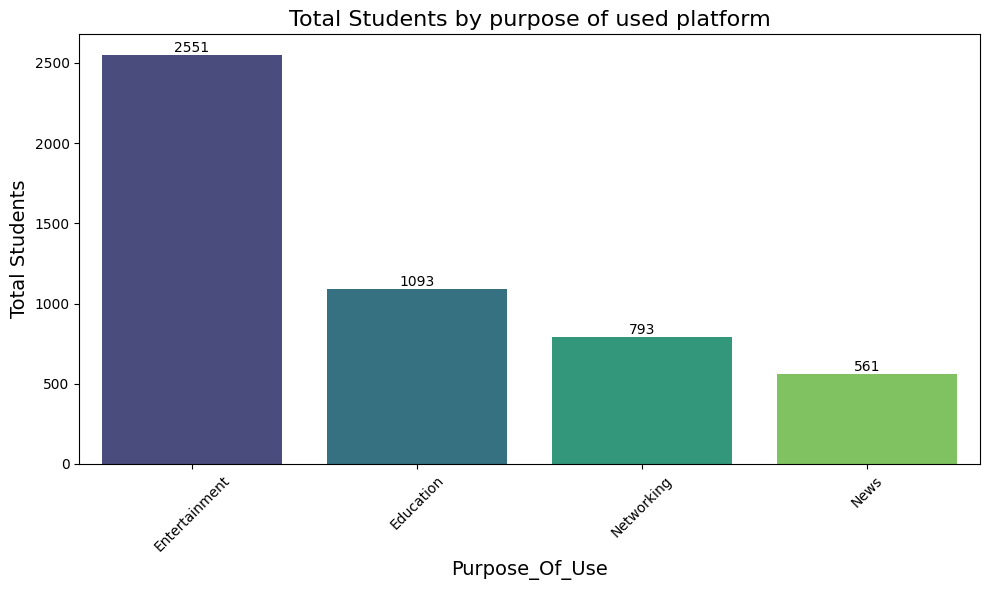

In [47]:
purpose_of_use = pd.read_sql_query(text("""select Purpose_Of_Use , count(*) as total_students , round(count(*) * 100.0 / sum(count(*)) over(),2) as pct_of_total from clean_dataset group by Purpose_Of_Use order by total_students desc """),engine)
display(purpose_of_use)
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=purpose_of_use,
    x="Purpose_Of_Use",
    y="total_students",
    hue="Purpose_Of_Use",
    palette="viridis"
)

# Add title and labels
plt.title("Total Students by purpose of used platform", fontsize=16)
plt.xlabel("Purpose_Of_Use", fontsize=14)
plt.ylabel("Total Students", fontsize=14)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 5),
        textcoords='offset points'
    )

# Show the plot
plt.tight_layout()
plt.show()


4. What are the average values of Avg_Daily_Usage_Hours, Sleep_Hours_Per_Night, Study_Hours, and Physical_Activity_Hours across the full dataset?

In [48]:
pd.read_sql_query(text("""select round(avg(Avg_Daily_Usage_Hours),2) as avg_daily_usage_hour , round(avg(Sleep_Hours_Per_Night),2) as sleep_hour ,round(avg(Study_Hours) ,2) as avg_study_hour , round(avg(Physical_Activity_Hours),2) as avg_physical_activity_hour from clean_dataset """),engine)

,avg_daily_usage_hour,sleep_hour,avg_study_hour,avg_physical_activity_hour
0,5.08,6.63,3.01,1.75


5. What does the distribution of Mental_Health_Score look like? Is it normally distributed, left-skewed, or right-skewed?

0.2065673061644126


Text(0, 0.5, 'Frequency')

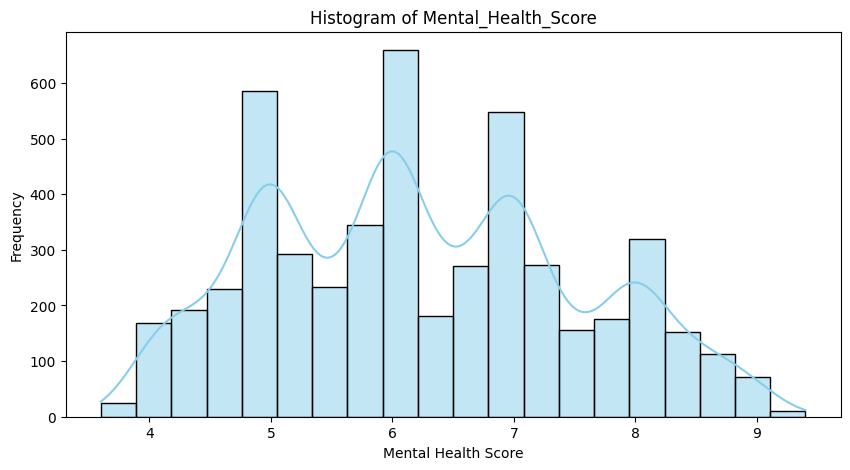

In [ ]:
print(df['Mental_Health_Score'].skew())
plt.figure(figsize=(10,5))
sns.histplot(df['Mental_Health_Score'], kde=True, color='skyblue', bins=20)
plt.title('Histogram of Mental_Health_Score')
plt.xlabel('Mental Health Score')
plt.ylabel('Frequency')

* The distribution of Mental_Health_Score appears approximately normal with a slight positive (right) skew. The skewness value is 0.206, which is close to zero and falls within the range of -0.5 to +0.5, indicating that the data is fairly symmetric.

* The histogram also shows most scores clustered around the center (5–7) with a slightly longer tail toward higher scores, suggesting mild right skewness but no severe departure from normality.

6. What is the breakdown of students across Stress_Level categories (Low / Medium / High / Very High)?

,Stress_Level,gender,total_students,pct_of_total
0,Very High,Male,841,16.83
1,Very High,Female,780,15.61
2,Medium,Male,731,14.63
3,High,Male,720,14.41
4,High,Female,719,14.39
5,Medium,Female,564,11.28
6,Low,Male,342,6.84
7,Low,Female,301,6.02


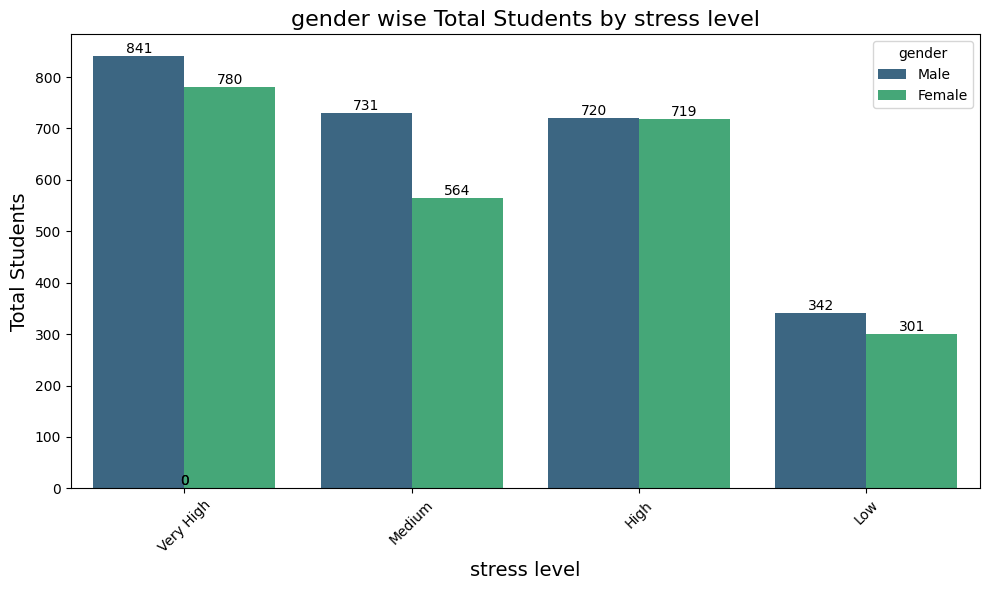

In [55]:
stress_level = pd.read_sql_query(text("""select  Stress_Level , gender , count(*) as total_students , round(count(*) * 100.0 / sum(count(*)) over(),2) as pct_of_total from clean_dataset group by Stress_Level , gender order by total_students desc """),engine)
display(stress_level)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=stress_level,
    x="Stress_Level",
    y="total_students",
    hue="gender",
    palette="viridis"
)

# Add title and labels
plt.title("gender wise Total Students by stress level", fontsize=16)
plt.xlabel("stress level", fontsize=14)
plt.ylabel("Total Students", fontsize=14)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 5),
        textcoords='offset points'
    )

# Show the plot
plt.tight_layout()
plt.show()


# Phase 2 : Diagnostic(what's driving what)

7. Does higher Avg_Daily_Usage_Hours correlate with lower Sleep_Hours_Per_Night and lower Study_Hours?

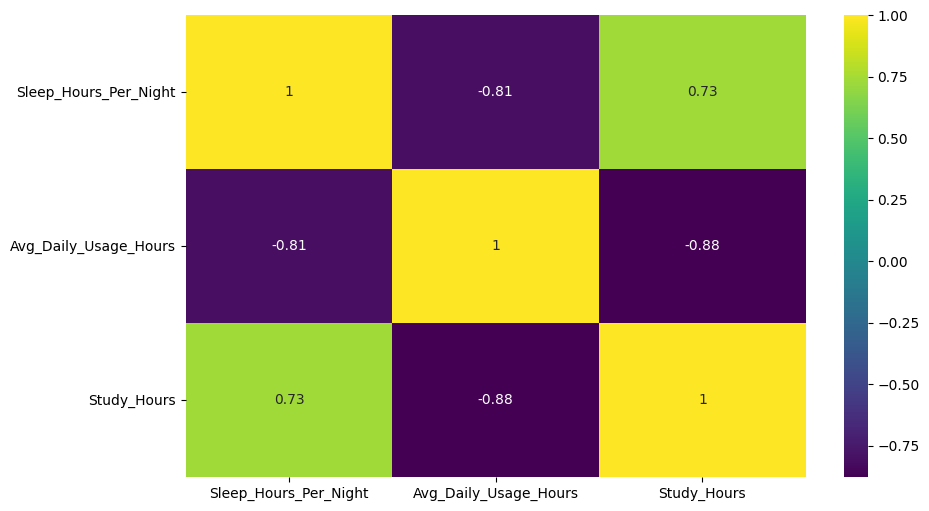

usage vs sleep distribution


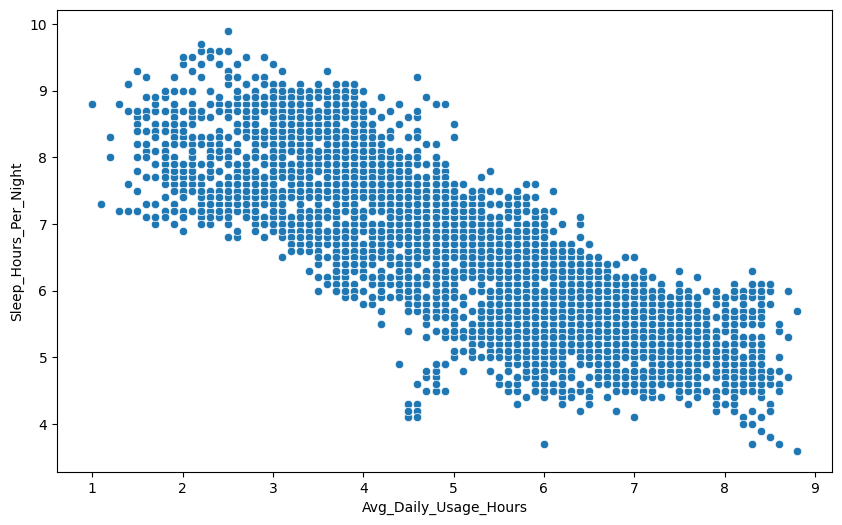

usage vs study hour distribution


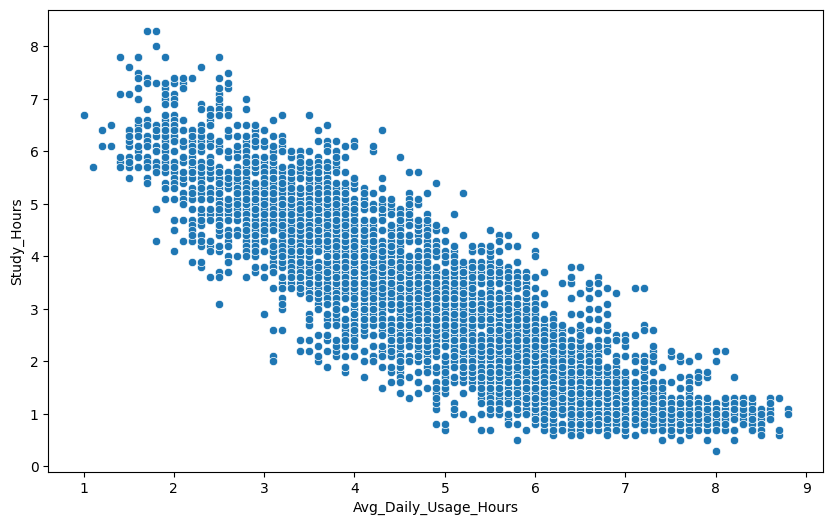

In [ ]:
cor = df[['Sleep_Hours_Per_Night' , 'Avg_Daily_Usage_Hours' , 'Study_Hours']]
plt.figure(figsize=(10,6))
sns.heatmap(cor.corr() , annot=True ,cmap="viridis" )
plt.show()

# usage vs sleep
print("usage vs sleep distribution")
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='Avg_Daily_Usage_Hours',
    y='Sleep_Hours_Per_Night'   
)
plt.show()

print("usage vs study hour distribution")

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Avg_Daily_Usage_Hours',
    y='Study_Hours'
)
plt.show()